In [ ]:
import heapq
import time

import math
import numpy as np
import matplotlib.pyplot as plt

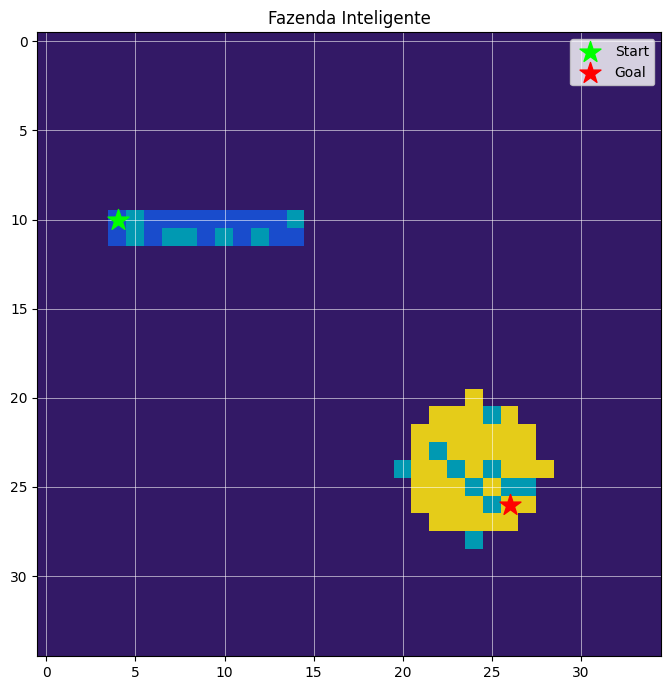

Parâmetros gerados:
  Retângulo:  linhas 10–12, colunas 4–15, obstáculos 21%


In [100]:
# Gera um campo de grid com obstáculos em forma de retângulo e círculo, e plota o resultado usando Matplotlib.

def generate_field(n_rows=35, n_cols=35, seed=None):
    """
    Gera um campo de grid com obstáculos em forma de retângulo e círculo.

    Args:
        n_rows (int, optional): Número de linhas do grid. Defaults to 35.
        n_cols (int, optional): Número de colunas do grid. Defaults to 35.
        seed (_type_, optional): Semente para geração de números aleatórios. Defaults to None.

    Returns:
        tuple: Uma tupla contendo o grid, posição de início, posição de destino, mapa de regiões e parâmetros.
    """

    if seed is not None:
        np.random.seed(seed) # Permite a reprodução dos mesmos parâmetros aleatórios se uma semente for fornecida, útil para testes consistentes

    # Parâmetros aleatórios do retângulo
    rect_r0 = np.random.randint(2, n_rows // 3) # Evita bordas e sorteia a posição inicial do retângulo
    rect_c0 = np.random.randint(2, n_cols // 3)
    rect_r1 = np.random.randint(n_rows // 3, 2 * n_rows // 3) # Garante que o retângulo tenha tamanho mínimo e fique centralizado
    rect_c1 = np.random.randint(n_cols // 3, 2 * n_cols // 3) 
    obstacle_ratio_rect = np.random.uniform(0.10, 0.40) # Proporção de obstáculos dentro do retângulo (10% a 40%)

    # Parâmetros aleatórios do círculo (quadrante oposto ao retângulo)
    cx = np.random.randint(2 * n_rows // 3, n_rows - 5) # Centro do círculo no quadrante oposto ao retângulo, evitando bordas
    cy = np.random.randint(2 * n_cols // 3, n_cols - 5) 
    radius = np.random.randint(4, min(n_rows, n_cols) // 5) # Raio do círculo entre 4 e 1/5 do menor lado do grid
    obstacle_ratio_circ = np.random.uniform(0.05, 0.30) # Proporção de obstáculos dentro do círculo (5% a 30%)

    # 1. Grid base limpo (sem obstáculos no fundo)
    grid = np.zeros((n_rows, n_cols), dtype=int)

    # 2. Limpa bordas
    grid[0, :] = 0; grid[:, 0] = 0
    grid[n_rows-1, :] = 0; grid[:, n_cols-1] = 0

    # 3. Região retangular com obstáculos
    rect_mask = np.zeros((n_rows, n_cols), dtype=bool) # Máscara para o retângulo
    rect_mask[rect_r0:rect_r1, rect_c0:rect_c1] = True # Define a região do retângulo
    rect_obstacles = np.random.rand(n_rows, n_cols) < obstacle_ratio_rect # Gera obstáculos aleatórios para o retângulo
    grid[rect_mask] = rect_obstacles[rect_mask].astype(int) # Preenche o retângulo com obstáculos de acordo com a proporção definida

    # 4. Região circular com obstáculos
    rows, cols = np.ogrid[:n_rows, :n_cols] # Gera matrizes de índices para calcular a máscara circular
    circ_mask = (rows - cx)**2 + (cols - cy)**2 <= radius**2 # Máscara para o círculo
    circ_obstacles = np.random.rand(n_rows, n_cols) < obstacle_ratio_circ # Gera obstáculos aleatórios para o círculo
    grid[circ_mask] = circ_obstacles[circ_mask].astype(int) # Preenche o círculo com obstáculos de acordo com a proporção definida

    # 5. Mapa de regiões (0=fundo, 1=retângulo, 2=círculo)
    region_map = np.zeros((n_rows, n_cols), dtype=int) # Inicializa o mapa de regiões com 0 (fundo)
    region_map[rect_mask] = 1 # Marca a região do retângulo com 1
    region_map[circ_mask] = 2 # Marca a região do círculo com 2 (sobrescreve o retângulo onde houver interseção, mas isso é raro devido à posição aleatória)

    # 6. Start no retângulo, goal no círculo
    free_rect = np.argwhere((grid == 0) & rect_mask) # Encontra células livres dentro do retângulo para o start
    free_circ = np.argwhere((grid == 0) & circ_mask) # Encontra células livres dentro do círculo para o goal

    assert len(free_rect) > 0, "Sem célula livre no retângulo! Reduza obstacle_ratio_rect."
    assert len(free_circ) > 0, "Sem célula livre no círculo! Reduza obstacle_ratio_circ."

    idx = np.random.randint(len(free_rect)) # Seleciona aleatoriamente uma célula livre no retângulo para o start
    start = tuple(free_rect[idx])
    idx = np.random.randint(len(free_circ)) # Seleciona aleatoriamente uma célula livre no círculo para o goal
    goal  = tuple(free_circ[idx])

    params = {
        "rect": (rect_r0, rect_c0, rect_r1, rect_c1),
        "obstacle_ratio_rect": round(obstacle_ratio_rect, 2),
        "circle": (cx, cy, radius),
        "obstacle_ratio_circ": round(obstacle_ratio_circ, 2),
    }

    return grid, start, goal, region_map, params


def plot_field(grid, start, goal, region_map, path = None):
    """
    Plota o campo gerado usando Matplotlib, destacando as regiões, obstáculos, start, goal e o caminho encontrado (se houver).

    Args:
        grid (_type_): grid de obstáculos e espaços livres.
        start (_type_): posição de início do caminho.
        goal (_type_): posição do objetivo do caminho.
        region_map (_type_): mapa de regiões.
        path (_type_, optional): lista de posições que representam o caminho encontrado. Defaults to None.
    """
    n_rows, n_cols = grid.shape # Obtém as dimensões do grid para criar o mapa de cores

    color_map = np.zeros((n_rows, n_cols, 3)) # Inicializa o mapa de cores (RGB) com zeros (preto)
    color_map[region_map == 0] = [0.2, 0.1, 0.4]  # roxo    (fundo)
    color_map[region_map == 1] = [0.1, 0.3, 0.8]  # azul    (retângulo)
    color_map[region_map == 2] = [0.9, 0.8, 0.1]  # amarelo (círculo)
    color_map[grid == 1]       = [0.0, 0.6, 0.7]  # ciano   (obstáculos)

    # Destaca o caminho encontrado, se houver
    if path:
        for cell in path:
            color_map[cell] = [1.0, 1.0, 1.0] # Caminho em branco para destacar a solução encontrada

    plt.figure(figsize=(7, 7)) # Define o tamanho da figura para melhor visualização
    plt.imshow(color_map, interpolation='nearest') # Exibe o grid usando o mapa de cores definido, sem interpolação para manter os blocos nítidos
    plt.title("Fazenda Inteligente") 
    plt.grid(True, color='white', linewidth=0.4) # Adiciona uma grade para melhor visualização das células

    # Start e Goal como estrelas
    plt.scatter(start[1], start[0], marker='*', s=250, color='lime', label='Start', zorder=5)
    plt.scatter(goal[1],  goal[0],  marker='*', s=250, color='red',  label='Goal',  zorder=5)

    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


# --- Executar ---
grid, start, goal, region_map, params = generate_field(n_rows=35, n_cols=35)

plot_field(grid, start, goal, region_map)

print("Parâmetros gerados:")
print(f"  Retângulo:  linhas {params['rect'][0]}–{params['rect'][2]}, colunas {params['rect'][1]}–{params['rect'][3]}, obstáculos {params['obstacle_ratio_rect']*100:.0f}%")

In [101]:
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)] # Movimentos possíveis: cima, baixo, esquerda, direita

def in_bounds(grid, p):
    """
    Verifica se a posição p está dentro dos limites do grid.
    
    Args:
        grid (_type_): grid de obstáculos e espaços livres.
        p (_type_): posição para encontrar vizinhos.

    Returns:
        bool: retorna True se a posição estiver dentro dos limites do grid, False caso contrário.
    """
    return 0 <= p[0] < grid.shape[0] and 0 <= p[1] < grid.shape[1]

def passable(grid, p):
    """
    Verifica se a posição p é passável (não é um obstáculo).
    
    Args:
        grid (_type_): grid de obstáculos e espaços livres.
        p (_type_): posição para encontrar vizinhos.

    Returns:
        bool: retorna True se a posição for passável, False caso contrário.
    """
    return grid[p] != 1

def neighbors(grid, p):
    """
    Encontra os vizinhos passáveis da posição p no grid.

    Args:
        grid (_type_): grid de obstáculos e espaços livres.
        p (_type_): posição para encontrar vizinhos.

    Returns:
        list: lista de posições vizinhas passáveis.
    """
    out = []
    for dr, dc in MOVES:
        q = (p[0]+dr, p[1]+dc)
        if in_bounds(grid,q) and passable(grid,q):
            out.append(q)
    return out

def cost(_, __):
    """
    Retorna o custo de mover-se de uma posição para outra.
    
    Args:
        _ (_type_): célula de origem (não utilizada, mas pode ser útil para custos variáveis).
        __ (_type_): célula de destino (não utilizada, mas pode ser útil para custos variáveis).

    Returns:
        _type_: retorna o custo de mover-se de uma posição para outra. Atualmente, retorna um custo
        fixo de 1.0, mas pode ser modificado para custos variáveis com base em diferentes critérios 
        (como tipo de terreno, presença de obstáculos, etc.).
    """
    return 1.0

def h_manhattan(p, goal):
    """
    Calcula a distância de Manhattan entre a posição p e o objetivo (goal).
    
    Args:
        p (_type_): posição para encontrar vizinhos.
        goal (_type_): posição do objetivo.

    Returns:
        float: retorna a distância de Manhattan entre a posição p e o objetivo (goal), que é a soma das diferenças absolutas das coordenadas.
    """
    return abs(p[0]-goal[0]) + abs(p[1]-goal[1])

def reconstruct_path(came_from, start, goal):
    """
    Reconstrói o caminho do objetivo (goal) de volta para o início (start) usando o dicionário came_from, que mapeia cada célula para a célula de onde veio.
    
    Args:
        came_from (_type_): dicionário que mapeia cada célula para a célula de onde veio, usado para reconstruir o caminho.
        start (_type_): posição de início do caminho.
        goal (_type_): posição do objetivo do caminho.

    Returns:
        _type_: retorna uma lista de posições que representam o caminho do início (start) ao objetivo (goal), reconstruído a partir
        do dicionário came_from. O caminho é invertido para que comece no início e termine no objetivo.
    """
    cur = goal
    path = [cur]
    while cur != start:
        cur = came_from[cur]
        path.append(cur)
    path.reverse()
    return path

In [102]:
def astar(grid, start, goal, E_max=None):
    """
    Implementa o algoritmo A* para encontrar o caminho mais curto do start ao goal em um grid, considerando obstáculos e um limite de energia (E_max).

    Args:
        grid (_type_): grid de obstáculos e espaços livres.
        start (_type_): posição de início do caminho.
        goal (_type_): posição do objetivo do caminho.
        E_max (_type_, optional): limite de energia. Defaults to None.

    Returns:
        list, dict: lista de posições que representam o caminho encontrado e um dict com inforções da performace do algoritmo.
    """
    t0 = time.perf_counter() # Marca o tempo de início para medir o tempo gasto pelo algoritmo
    open_heap = [] # Fila de prioridade para os nós abertos, ordenada por f(n) = g(n) + h(n)
    heapq.heappush(open_heap, (h_manhattan(start, goal), 0, start)) # Inicializa a fila de prioridade com o nó inicial, onde f(n) é a heurística (distância de Manhattan) e g(n) é 0
    came_from = {} # Dicionário para reconstruir o caminho, mapeando cada célula para a célula de onde veio
    g_score = {start: 0.0} # Dicionário que mantém o custo g(n) do caminho mais barato encontrado até cada célula, inicializado com o custo do start como 0
    closed = set() # Conjunto de nós fechados (já expandidos) para evitar reprocessamento
    expanded = 0 # Contador de nós expandidos para métricas de desempenho

    while open_heap:
        _, _, current = heapq.heappop(open_heap) # Remove o nó com o menor f(n) da fila de prioridade para expansão 
        # Verifica se o nó atual já foi fechado (expandido) para evitar reprocessamento
        if current in closed:
            continue
        closed.add(current) # Adiciona nó no conjunto de fechados para marcar como expandido
        expanded += 1 # Incrementa o contador de nós expandidos para métricas de desempenho

        # Se ele encontrar o objetivo, reconstrói o caminho e retorna os resultados
        if current == goal:
            path = reconstruct_path(came_from, start, goal)
            return path, {
                "algoritmo": "A*",
                "nos_expandidos": expanded,
                "tempo_s": time.perf_counter() - t0,
                "energia": g_score[goal]
            }
        # Pega os nós vizinhos do nó atual e calcula o custo tentativo g(n) para cada vizinho 
        for nxt in neighbors(grid, current):
            tentative_g = g_score[current] + cost(current, nxt)

            # Descarta se ultrapassar a energia máxima
            if E_max is not None and tentative_g > E_max:
                continue
            
            # Se o vizinho ainda não foi visitado ou se o caminho tentativo para o vizinho é mais barato 
            # do que qualquer caminho anteriormente registrado, atualiza os dados do vizinho e o adiciona 
            # à fila de prioridade para futura expansão
            if nxt not in g_score or tentative_g < g_score[nxt]:
                came_from[nxt] = current
                g_score[nxt] = tentative_g
                f = tentative_g + h_manhattan(nxt, goal)
                heapq.heappush(open_heap, (f, expanded, nxt))

    return [], {
        "algoritmo": "A*",
        "status": "falha — sem caminho ou E_max muito baixo",
        "nos_expandidos": expanded,
        "tempo_s": time.perf_counter() - t0
    }


In [103]:
def ida_star(grid, start, goal, E_max=None):
    """
    O ida_star é um algoritmo que reutiliza o dfs onde ele apenas gerencia o limit e decide quando aumentar. Ele só aumenta se o limit for excedido e o goal não for encontrado.

    Args:
        grid (_type_): grid de obstáculos e espaços livres.
        start (_type_): posição de início do caminho.
        goal (_type_): posição do objetivo do caminho.
        E_max (_type_, optional): limite de energia. Defaults to None.

    Returns:
        list, dict: lista de posições que representam o caminho encontrado e um dict com inforções da performace do algoritmo.

    """

    t0 = time.perf_counter() # Marca o tempo de início para medir o tempo gasto pelo algoritmo
    expanded = 0 # Contador de nós expandidos para métricas de desempenho

    def dfs(node, g, limit, came_from, visited):
        # Permite que uma função interna modifique uma variável da função externa que a contém.
        nonlocal expanded

        # Calcula o custo total estimado desse caminho:
        # g = custo real percorrido até aqui
        # h_manhattan = estimativa da distância daqui até o goal
        # Se f ultrapassar o limit atual, abandona esse caminho e volta
        # O limit começa como h_manhattan(start, goal) mas aumenta a cada iteração
        f = g + h_manhattan(node, goal)
        
        if f > limit:
            return None, f
        
        if node == goal:
            return node, f

        expanded += 1

        # Ainda não encontrei nenhum custo rejeitado
        min_excess = math.inf
        for nxt in neighbors(grid, node):

            # Descarta se ultrapassar a energia máxima
            if E_max is not None and g > E_max:
                continue
        
            if nxt in visited:
                continue

            came_from[nxt] = node

            visited.add(nxt)
            found, bound = dfs(nxt, g+1, limit, came_from, visited)
            
            if found is not None:
                return found,bound
            
            min_excess = min(min_excess, bound)

            visited.remove(nxt)
        
        return None, min_excess

    # Utilizado para calcular a distancia do incio para o final
    limit = h_manhattan(start, goal)
    came_from = {}
    visited = {start}

    while True:
        found, next_limit = dfs(start, 0, limit, came_from, visited)

        if E_max is not None and expanded >= E_max:
            return [], {"algoritmo":"IDA*","status":"falha - bateria acabou"}

        if found is not None:
            path = reconstruct_path(came_from,start,goal)
            return path, {"algoritmo":"IDA*","nos_expandidos":expanded,"tempo_s":time.perf_counter()-t0}
        
        if next_limit == math.inf:
            return [], {"algoritmo":"IDA*","status":"falha"}
        
        limit = next_limit

In [104]:
def rbfs(grid, start, goal, E_max=None):
    """
    O RBFS é um algoritmo recursivo de busca best-first que usa memória limitada.
    Ele explora o melhor caminho disponível mas guarda o segundo melhor como alternativa,
    permitindo voltar (backtrack) se o caminho atual ficar caro demais.

    Args:
        grid: grid de obstáculos e espaços livres.
        start: posição de início do caminho.
        goal: posição do objetivo do caminho.
        E_max: limite de energia. Defaults to None.

    Returns:
        list, dict: lista de posições que representam o caminho encontrado
                    e um dict com informações de performance do algoritmo.
    """

    t0 = time.perf_counter()  # Marca o tempo de início para medir o tempo gasto pelo algoritmo
    expanded = 0               # Contador de nós expandidos para métricas de desempenho
    came_from = {}             # Guarda o caminho percorrido para reconstrução ao final

    def rbfs_rec(node, g, f_node, limit, visited):
        nonlocal expanded

        # Se chegou ao goal, retorna sucesso
        if node == goal:
            return node, f_node

        expanded += 1

        # Gera os sucessores do nó atual
        succ = []
        for nxt in neighbors(grid, node):

            # Descarta se o vizinho já foi visitado nesse caminho (evita ciclos)
            if nxt in visited:
                continue

            # Descarta se a energia consumida ultrapassar E_max
            g2 = g + 1
            if E_max is not None and g2 > E_max:
                continue

            # f2 = max entre o custo estimado do vizinho e o f do nó atual
            # O max garante que o f nunca decresce ao longo do caminho
            f2 = max(g2 + h_manhattan(nxt, goal), f_node)
            succ.append([f2, g2, nxt])

        # Se não há sucessores válidos, retorna falha com custo infinito
        if not succ:
            return None, math.inf

        while True:
            # Ordena os sucessores pelo menor f — o melhor candidato fica em succ[0]
            succ.sort(key=lambda x: x[0])
            best_f, best_g, best = succ[0]

            # Se o melhor sucessor ultrapassa o limite, abandona e devolve o custo
            if best_f > limit:
                return None, best_f

            # alt = f do segundo melhor sucessor (ou infinito se só há um)
            # Limita a exploração ao mínimo entre o limit atual e o segundo melhor
            # Isso evita explorar além do necessário antes de considerar alternativas
            alt = succ[1][0] if len(succ) > 1 else math.inf
            came_from[best] = node
            visited.add(best)
            found, new_f = rbfs_rec(best, best_g, best_f, min(limit, alt), visited)
            visited.remove(best)  # Backtrack — remove ao voltar para tentar outro caminho

            # Atualiza o f do melhor sucessor com o valor retornado pela recursão
            succ[0][0] = new_f

            if found is not None:
                return found, new_f

    visited = {start}
    found, _ = rbfs_rec(start, 0, h_manhattan(start, goal), math.inf, visited)

    if found is None:
        return [], {
            "algoritmo": "RBFS",
            "status": "falha — sem caminho ou E_max muito baixo",
            "nos_expandidos": expanded,
            "tempo_s": time.perf_counter() - t0
        }

    path = reconstruct_path(came_from, start, goal)
    return path, {
        "algoritmo": "RBFS",
        "nos_expandidos": expanded,
        "tempo_s": time.perf_counter() - t0,
        "energia": len(path) - 1  # energia = número de movimentos do drone
    }

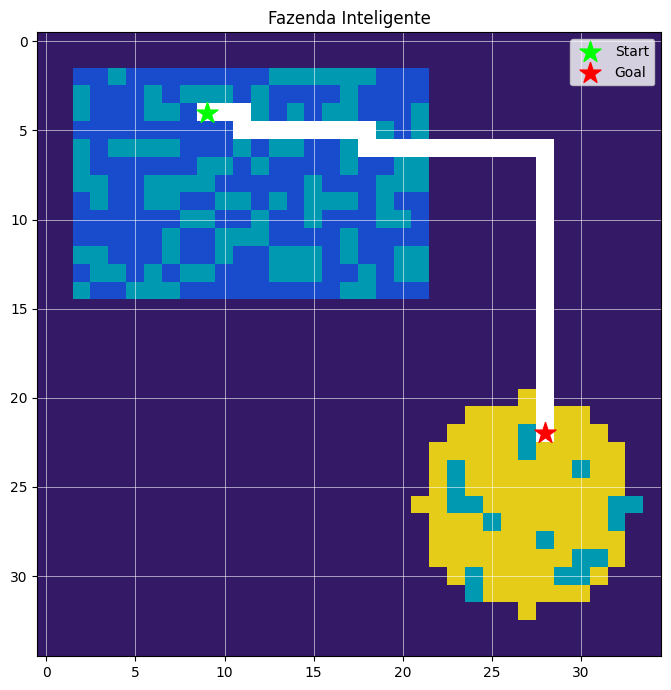

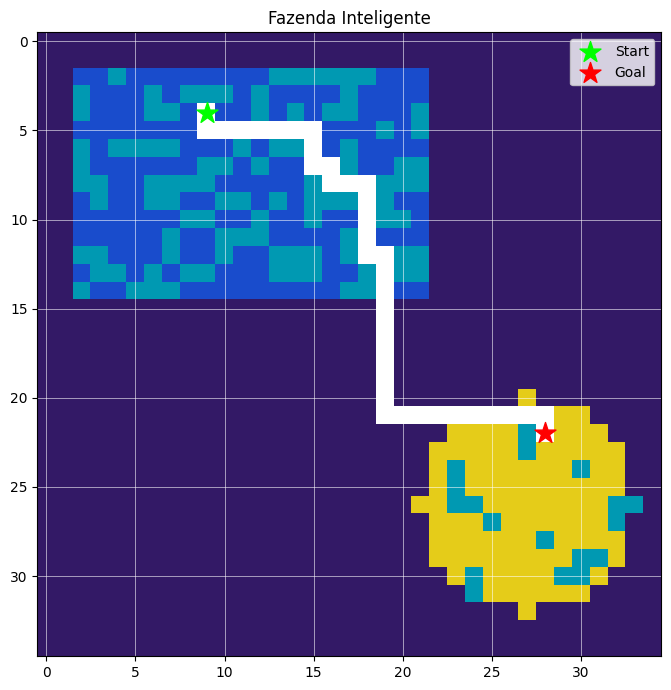

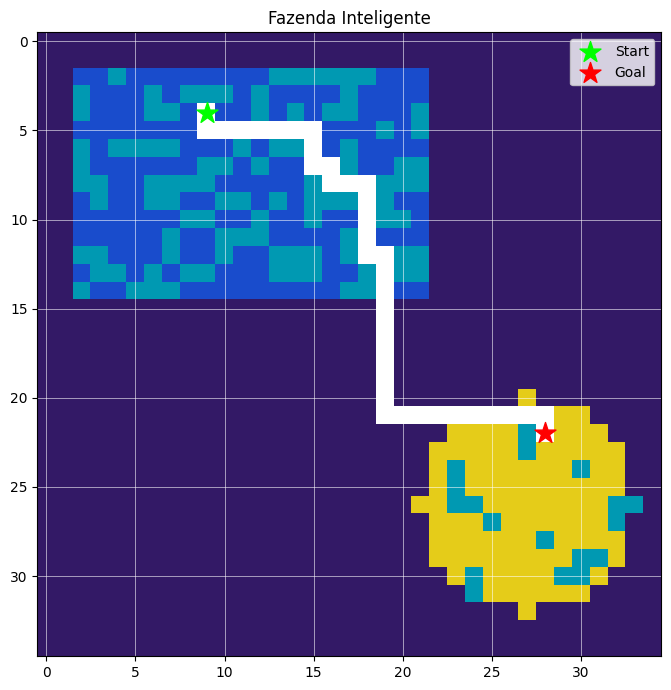

In [105]:
# --- Executar ---
grid, start, goal, region_map, params = generate_field(n_rows=35, n_cols=35)

path, metrics = astar(grid, start, goal, E_max=100)
plot_field(grid, start, goal, region_map, path)
time.sleep(5)
path, metrics = ida_star(grid, start, goal, E_max=100)  
time.sleep(5)
plot_field(grid, start, goal, region_map, path)
path, metrics = rbfs(grid, start, goal, E_max=100)  
plot_field(grid, start, goal, region_map, path)

